## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


## Preguntas

1. ¿Cuál es la variable objetivo? **R= income**
2. ¿Qué representa dicha variable? **R = El ingreso de las personas**
3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona? **R= education, occupation, hours per week, marital status, age, capital gain y también workclass**
4. ¿Cuántas variables predictoras existen? **R= Una variable**
5. ¿Por qué fue necesario transformar variables categóricas? **R=Porque el modelo requiere valores numéricos.**
7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?**82**
8. ¿Existen valores nulos?**R=Sí**
9. ¿Qué variables son numéricas?**R='age',
 'fnlwgt',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week'**
10. ¿Qué variables son categóricas?**R='workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country'**
11. ¿Cuántos registros quedaron en entrenamiento?**R=24129**
12. ¿Cuántos registros quedaron en prueba?**R= 6033**
13. ¿Por qué no debemos entrenar utilizando todos los datos?**R=Porque se necesita un conjunto de prueba independiente para evaluar si el modelo generaliza a datos nuevos.**
14. ¿Cuál fue el Accuracy obtenido?**R=83.76%**
15. ¿Consideras que el resultado es adecuado?**R=Pues sí, es aceptable como modelo base, aunque puede mejorar.**
16. ¿Qué factores podrían afectar el desempeño del modelo?**R=Desbalance de clases, calidad de datos, valores nulos, variables irrelevantes, profundidad del árbol y codificación de variables.**
18. ¿Cuál fue la variable más importante?**R= marital_status_Married-civ-spouse**
19. ¿Cuál fue la menos importante?**R=education_11th**
20. ¿Coinciden los resultados con tus hipótesis iniciales?**R=Yo diría qu esí, porque variables educativas, laborales y de capital suelen aparecer entre las más relevantes.**
21. ¿Qué variables aportan más información al modelo?**R=capital_gain, age , capital_loss,hours_per_week**

# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Laboratorio12.ipynb
```

---


## Paso 1. Importar librerías

In [44]:
import pandas as pd 
import numpy as np 
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
path = kagglehub.dataset_download("uciml/adult-census-income")

In [3]:
# Imprimir el dataset
print("Ruta del dataset:", path)

Ruta del dataset: /home/karl/.cache/kagglehub/datasets/uciml/adult-census-income/versions/3


In [4]:
dfCensus = pd.read_csv(path + "/adult.csv")

In [5]:
dfCensus.head(20)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [6]:
dfCensus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
dfCensus.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Paso 2. Realizar el análisis
- Se deberán normalizar los nombres de las columnas ya que contienen caracteres que pueden alterar el funcionamiento.
- Realizar una copia de seguridad
- Verificar si la normalización fue exitosa

In [9]:
def normalizeColumns (dfCensus:pd.DataFrame) -> pd.DataFrame:
    df = dfCensus.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(".", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace(" ", "_", regex=False)
    )
    return df

In [12]:
dfCensus = normalizeColumns(dfCensus)

In [15]:
# Mostrará los nombres de las columnas con la normalización que aplicamos anteriormente
dfCensus.head(5)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [16]:
dfCensus["income"].value_counts(dropna=False)

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [17]:
# Aquí obtendremos el porcentaje de cada clase
dfCensus["income"].value_counts(normalize=True, dropna=False) * 100

income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64

## Paso 3. Realizar una limpieza pra los espacios vacíos


In [20]:
df = dfCensus.copy()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace("?", np.nan)

df["income"] = ( df["income"].str.replace(".", "", regex=False).str.strip())

print("Valores de income después de la limpieza:")
display(df["income"].value_counts(dropna=False))

Valores de income después de la limpieza:


income
<=50K    24720
>50K      7841
Name: count, dtype: int64

## Paso 4. Realizar la eliminación de valores nulos

In [22]:
nullValues = df.isnull().sum().sort_values(ascending=False)
nullValues = nullValues[nullValues > 0]

print("Valores nulos por columna:")
nullValues if len(nullValues) > 0 else "No hay valores nulos detectados."

print("Registros antes de eliminar los valores nulos:", df.shape[0])
df = df.dropna().reset_index(drop=True)
print("Registros después de eliminar los valores nulos:", df.shape[0])

Valores nulos por columna:
Registros antes de eliminar los valores nulos: 30162
Registros después de eliminar los valores nulos: 30162


## Hipótesis
Algunas variables podrían influir en la capacidad de generar más ingresos, así como la ocupación y el sector laboral, las horas de trabajo son indispensables por que influyen directamente en los ingresos obtenidos. 
Asimismo, los movimientos que se tienen en capital y la edad pueden ser factores que resulten relevantes.

In [29]:
# Primero convertiremos la variable a binarios para poder realizar los cálculos pertinentes
df["income_binary"] = df["income"].map({"<=50K": 0, ">50K": 1})
if df["income_binary"].isnull().any():
    raise ValueError("Existen clases en income no reconocidas. Revisa los valores únicos de la columna income.")
numericColumns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numericColumnsWithoutTarget = [c for c in numericColumns if c != "income_binary"]

print("Variables numéricas:")
display(numericColumnsWithoutTarget)

correlations = (
    df[numericColumnsWithoutTarget + ["income_binary"]]
    .corr(numeric_only=True)["income_binary"]
    .sort_values(ascending=False)
)

print("Correlación de variables numéricas con income_binary:" , correlations)

Variables numéricas:


['age',
 'fnlwgt',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

Correlación de variables numéricas con income_binary: income_binary     1.000000
education_num     0.335286
age               0.241998
hours_per_week    0.229480
capital_gain      0.221196
capital_loss      0.150053
fnlwgt           -0.008957
Name: income_binary, dtype: float64


## Paso 5. Graficar las correlaciones

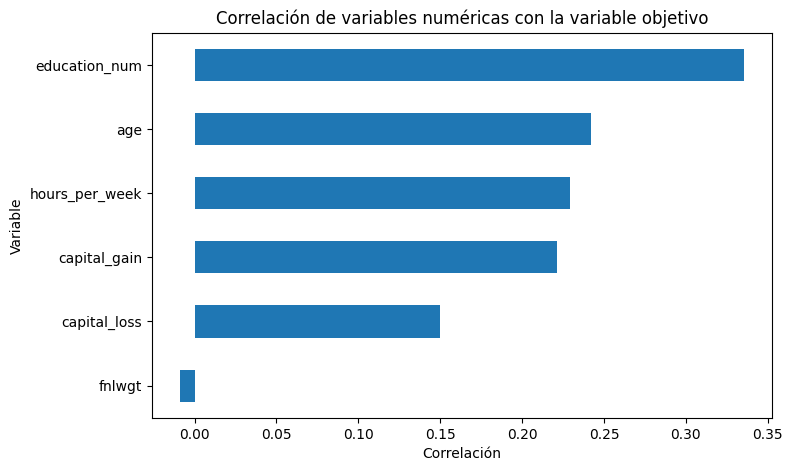

In [30]:
plt.figure(figsize=(8, 5))
correlations.drop("income_binary").sort_values().plot(kind="barh")
plt.title("Correlación de variables numéricas con la variable objetivo")
plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.show()

## Paso 6. Definición de las variables predictorias y objetivo

In [31]:
# Definir la variable objetivo
y = df["income_binary"]

# Definir las variables predictorias
X = df.drop(columns=["income", "income_binary"])

numericColumns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categoricColumns = X.select_dtypes(include=["object"]).columns.tolist()

print("Variable objetivo: income_binary")
print("Total de variables predictorias:", X.shape[1])

print("\nVariables numéricas:")
display(numericColumns)

print("\nVariables categóricas:")
display(categoricColumns)

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Variable objetivo: income_binary
Total de variables predictorias: 14

Variables numéricas:


['age',
 'fnlwgt',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']


Variables categóricas:


['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']


Dimensiones de X: (30162, 14)
Dimensiones de y: (30162,)


## Paso 7. Transformación de las variables a binario para el entrenamiento 

In [35]:
BeforeEncode = X.shape[1]

X_encoded = pd.get_dummies(
    X,
    columns=categoricColumns,
    drop_first=True,
    dtype=int
)

AfterEncode = X_encoded.shape[1]
AdditionalColumns = AfterEncode - BeforeEncode

print("Columnas antes del encode:", BeforeEncode)
print("Columnas después del encode:", AfterEncode)
print("Columnas adicionales generadas:", AdditionalColumns)

display(X_encoded.head(5))

Columnas antes del encode: 14
Columnas después del encode: 96
Columnas adicionales generadas: 82


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,82,132870,9,0,4356,18,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,54,140359,4,0,3900,40,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,41,264663,10,0,3900,40,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,34,216864,9,0,3770,45,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,38,150601,6,0,3770,40,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


## Paso 8. Datos Train/Test 

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=7,
    stratify=y
)

print("Registros de entrenamiento:", X_train.shape[0])
print("Registros de prueba:", X_test.shape[0])
print("Columnas finales usadas por el modelo:", X_train.shape[1])

Registros de entrenamiento: 24129
Registros de prueba: 6033
Columnas finales usadas por el modelo: 96


## Paso 9. Standar Scaler

In [37]:
scaler = StandardScaler()

# Se crea una copia para evitar problemas
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numericColumns] = scaler.fit_transform(X_train_scaled[numericColumns])
X_test_scaled[numericColumns] = scaler.transform(X_test_scaled[numericColumns])

display(X_train_scaled.head())

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
12288,0.418205,0.113865,1.124545,-0.148025,-0.218185,-0.493564,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4363,-1.175569,2.012932,-2.782685,-0.148025,-0.218185,-0.077937,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6910,-1.327357,3.841069,-0.047624,-0.148025,-0.218185,-0.077937,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1369,0.418205,0.086557,-0.047624,-0.148025,3.190405,-0.077937,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
6044,-0.492523,-1.022612,-0.438347,-0.148025,-0.218185,1.584569,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


## Paso 10. Decision Tree

In [39]:
modelo = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=7
)

modelo.fit(X_train_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",7
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

## Paso 11. Comenzar con las predicciones 

In [40]:
y_pred = modelo.predict(X_test_scaled)

predictionResults = pd.DataFrame({
    "valor_real": y_test.values,
    "prediccion": y_pred
})

display(predictionResults.head(10))

,valor_real,prediccion
0,0,0
1,0,0
2,0,0
3,1,0
4,0,0
5,1,1
6,0,0
7,0,0
8,0,0
9,1,0


## Paso 12. Evaluamos la exactitud 

In [45]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy obtenido: {accuracy:.4f}")
print(f"Accuracy en porcentaje: {accuracy * 100:.2f}%")

print("\nMatriz de confusión:")
display(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Real <=50K", "Real >50K"],
    columns=["Pred <=50K", "Pred >50K"]
))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

Accuracy obtenido: 0.8376
Accuracy en porcentaje: 83.76%

Matriz de confusión:


,Pred <=50K,Pred >50K
Real <=50K,4294,237
Real >50K,743,759



Reporte de clasificación:
              precision    recall  f1-score   support

       <=50K       0.85      0.95      0.90      4531
        >50K       0.76      0.51      0.61      1502

    accuracy                           0.84      6033
   macro avg       0.81      0.73      0.75      6033
weighted avg       0.83      0.84      0.83      6033



## Paso 13. Realizamos el análisis de las variables más y menos importantes

In [46]:
importants = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "importance": modelo.feature_importances_
}).sort_values(by="importance", ascending=False)

relevantValues = importants[importants["importance"] > 0].copy()

print("Top 15 variables más importantes:")
display(importants.head(15))

print("Variables usadas realmente por el árbol:")
display(relevantValues)

MostImpVar = importants.iloc[0]["feature"]
LessImpVar = importants.sort_values(by="importance", ascending=True).iloc[0]["feature"]

print("Variable más importante:", MostImpVar)
print("Variable menos importante:", LessImpVar)

Top 15 variables más importantes:


,feature,importance
28,marital_status_Married-civ-spouse,0.467189
2,education_num,0.240119
3,capital_gain,0.210827
0,age,0.032107
4,capital_loss,0.026566
5,hours_per_week,0.019880
1,fnlwgt,0.002321
24,education_Preschool,0.000501
9,workclass_Self-emp-not-inc,0.000388
36,occupation_Farming-fishing,0.000103


Variables usadas realmente por el árbol:


,feature,importance
28,marital_status_Married-civ-spouse,0.467189
2,education_num,0.240119
3,capital_gain,0.210827
0,age,0.032107
4,capital_loss,0.026566
5,hours_per_week,0.019880
1,fnlwgt,0.002321
24,education_Preschool,0.000501
9,workclass_Self-emp-not-inc,0.000388
36,occupation_Farming-fishing,0.000103


Variable más importante: marital_status_Married-civ-spouse
Variable menos importante: education_11th


## Paso 14. Realizar la graficación de las variables

<Figure size 1000x600 with 0 Axes>

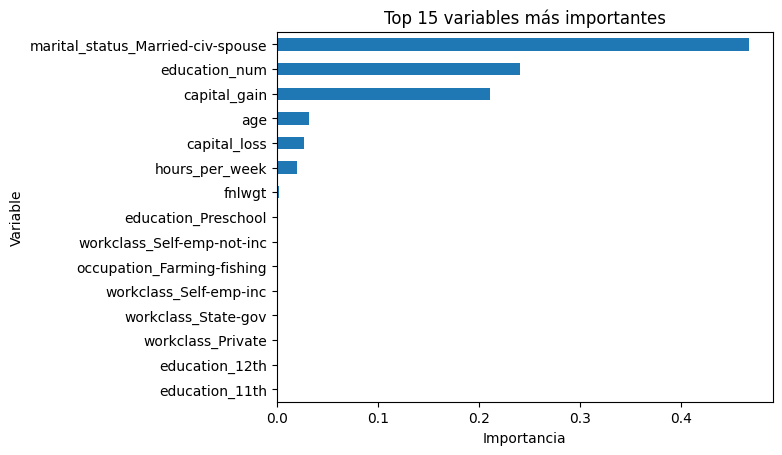

In [47]:
plt.figure(figsize=(10, 6))
importants.head(15).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)
plt.title("Top 15 variables más importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## Paso 15. Graficar el Árbol de Decisión 

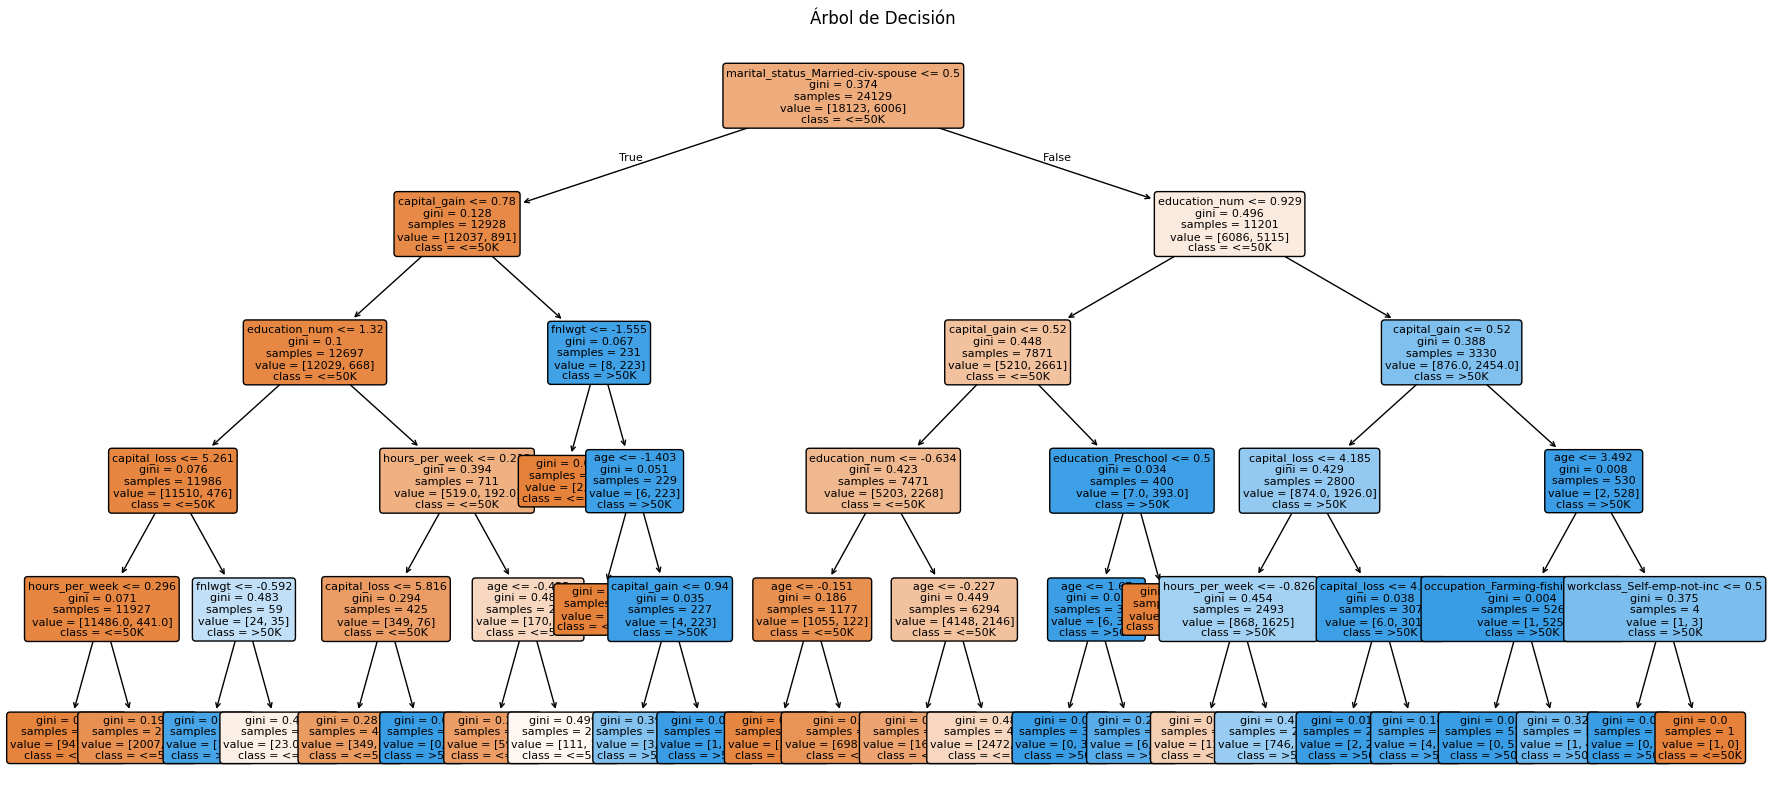

In [50]:
plt.figure(figsize=(22, 10))
plot_tree(
    modelo,
    feature_names=X_train_scaled.columns,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol de Decisión")
plt.show()

## Concluciones obtenidas

El preprocesamiento de los datos, permitió convertir un dataset con variables numéricas y categóricas en una matriz apta para Machine Learning.

Conclusiones principales:

- La variable objetivo fue `income`.
- El problema corresponde a clasificación binaria.
- Fue necesario limpiar valores faltantes representados como `?`.
- Las variables categóricas se transformaron mediante `One-Hot Encoding`.
- Se dividieron los datos en entrenamiento y prueba para evitar evaluar el modelo con los mismos datos usados en el entrenamiento.
- Se aplicó `StandardScaler` solo a  variables numéricas.
- El Árbol de Decisión permitió obtener una métrica de exactirud y analizar la importancia de las variables.
- Las variables con mayor importancia ayudan a interpretar qué factores están más asociados con ingresos superiores a 50K.